<p align="left">
<img src="https://raw.githubusercontent.com/dewdotninja/exams/main/feng_heading_en.png" width=400 alt="Feng heading"/>
</p>

#### Homework 5 : 
<p />01211373 Machine Learning and Programming for Industry
<p />Academic year 2025. First semester.

**Important :** Type your name and student ID in the cell below. (Failing to do so results in -1 point penalty.)


In [1]:
# student's name - surname,  ID

In [2]:
# import libraries you want to use
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

***
### List of Homework problems (total 10 points)

* [P1. (5 points)](#p1)
* [P2. (5 points)](#p2)


<a id="p1"></a>
#### P1. (5 points)

By following the steps on p. 141 (chapter 5) of [1], apply PCA algorithm for dimensionality reduction on the iris dataset. You can use scikit-learn or do it stp by step as in lecture 7 notebook. Split data to 70% training examples and 30% test examples. 

**P 1.1** (2 points) Plot the proportion of the total variance captured by the principal components, as in Figure 5.2 (p. 145)

**P 1.2** (2 points) Select only the first 2 principal components so that you can plot in 2D. Use **decision tree algorithm** to classify the iris dataset for the 3 classes (Sesota, Versicolor, Virginica). Plot decision regions for both training and test examples. Limit maximum depth of the tree to prevent overfitting. 

**P 1.3** (1 point) Assess feature contributions by plotting feature correlations with the first principal component as shown in Figure 5.6 (p. 153)

**Note :** Make sure that all labels in your graphs convey correct information to the reader. Failure to do so would result in score deduction. 


In [3]:
from sklearn import datasets
iris = datasets.load_iris()
X = iris.data
y = iris.target

### Solution

#### P 1.1

In [4]:
# split data to 70% training and 30% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


Perform PCA step by step as in lecture 7 notebook.

**Step 1 :** Standardize the data.

In [5]:
# standardize the data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

**Step 2 :** Construct the covariance matrix.

In [6]:
cov_mat = np.cov(X_train_std.T)

**Step 3 :** perform eigen decompositon of the covariance matrix

In [7]:
eigen_vals, eigen_vecs = np.linalg.eigh(cov_mat)
print('\nEigenvalues \n', eigen_vals)


Eigenvalues 
 [0.01938501 0.13823146 0.95479387 2.9260512 ]


In [8]:
eigen_vecs

array([[ 0.28933299,  0.70557265,  0.38039416, -0.523215  ],
       [-0.12829262, -0.25874261,  0.92371023,  0.25169956],
       [-0.80454783, -0.11116789,  0.01602484, -0.58317039],
       [ 0.50252385, -0.65027779,  0.04246043, -0.56815992]])

**Step 4 :** Sort the eigenvalues by decreasing order and plot the proportionof total variance captured by the principal components, as in Figure 5.2 of [1].

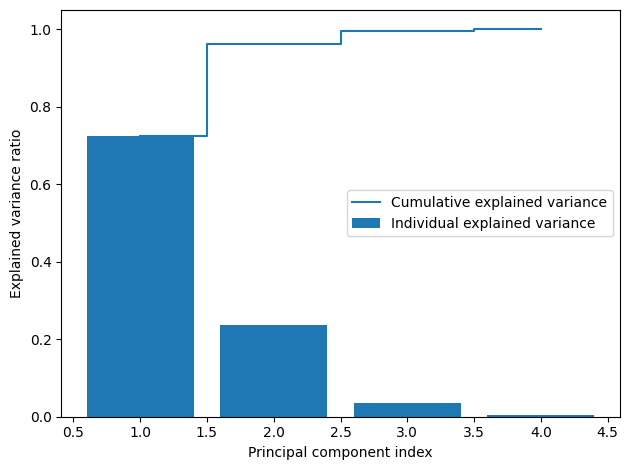

In [9]:
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

import matplotlib.pyplot as plt
plt.bar(range(1, 5), var_exp, align='center',
        label='Individual explained variance')
plt.step(range(1, 5), cum_var_exp, where='mid',
         label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Sort the eigenvalues and select only the first 2 principal components.

In [10]:
# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

we collect the two eigenvectors that correspond to the two largest eigenvalues, to capture more than 90 percent of the variance in this iris dataset.

In [11]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))
print('Matrix W:\n', w)

Matrix W:
 [[-0.523215    0.38039416]
 [ 0.25169956  0.92371023]
 [-0.58317039  0.01602484]
 [-0.56815992  0.04246043]]


We can transform the entire 105x4-dimensional training dataset onto the two principal
components by calculating the matrix dot product
$$
X^′ = XW \tag{7.10}
$$

In [12]:
X_train_pca = X_train_std.dot(w)

Using scikit-learn should yield similar results.

In [13]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.72454601, 0.23642515, 0.03422874, 0.0048001 ])

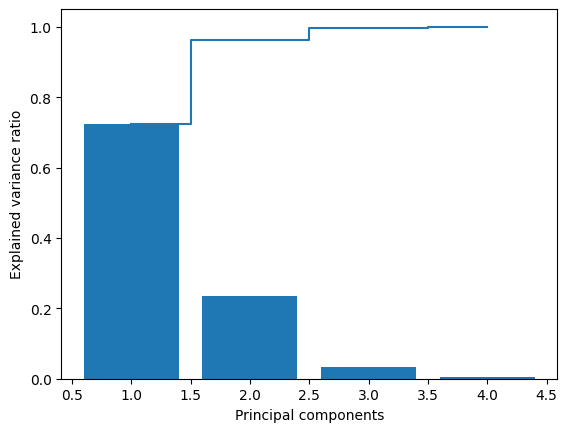

In [14]:
plt.bar(range(1, 5), pca.explained_variance_ratio_, align='center')
plt.step(range(1, 5), np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')

plt.show()

#### P 1.2

Let’s visualize the transformed iris training dataset, now stored as an 105×2-dimensional
matrix, in a two-dimensional scatterplot.

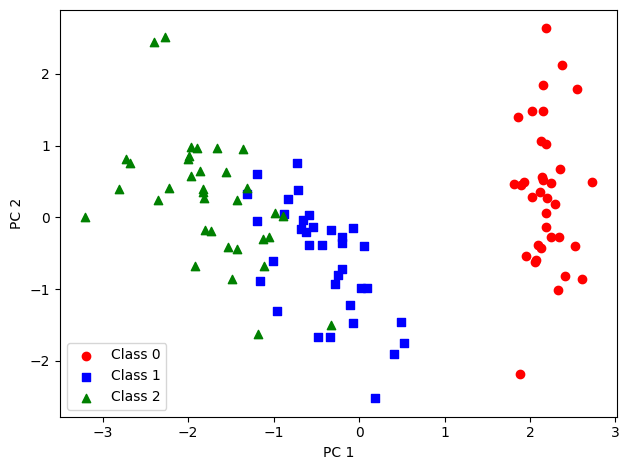

In [15]:
X_train_pca = X_train_std.dot(w)

colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0], 
                X_train_pca[y_train == l, 1], 
                c=c, label=f'Class {l}', marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

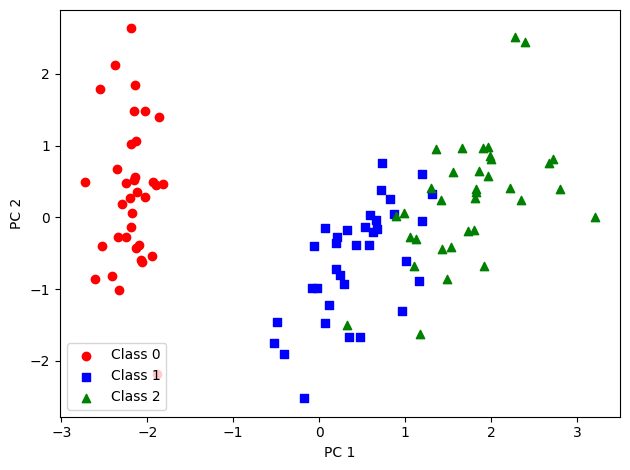

In [16]:
# if use scikit-learn
pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)

colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0], 
                X_train_pca[y_train == l, 1], 
                c=c, label=f'Class {l}', marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Use decision tree algorithm to classify and plot boundary decision region.

In [17]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100, 
                    label='Test set')        

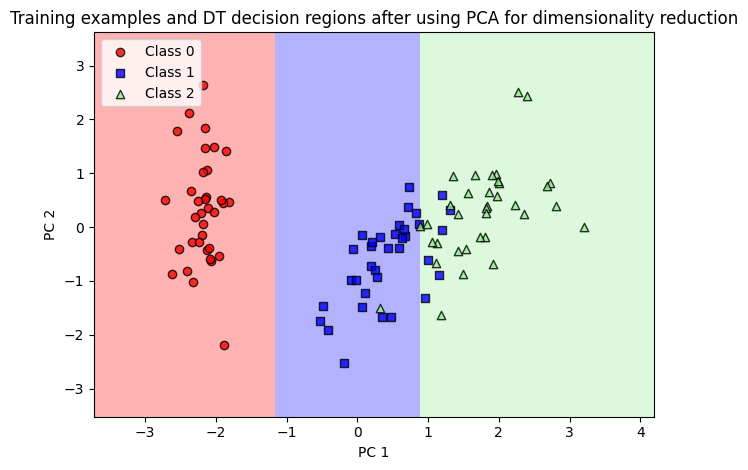

In [18]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

from sklearn.tree import DecisionTreeClassifier

# try changing the hyperparameters such as criterion = 'entropy','gini','log_loss'
# incresing max_depth would result in overfitting. Set it to 2 yields best result. 
tree_model = DecisionTreeClassifier(criterion='gini', 
                                    max_depth=2, 
                                    random_state=1)
tree_model.fit(X_train_pca, y_train)

plot_decision_regions(X_train_pca, y_train, classifier=tree_model)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='upper left')
plt.title('Training examples and DT decision regions after using PCA for dimensionality reduction')
plt.tight_layout()
plt.show()

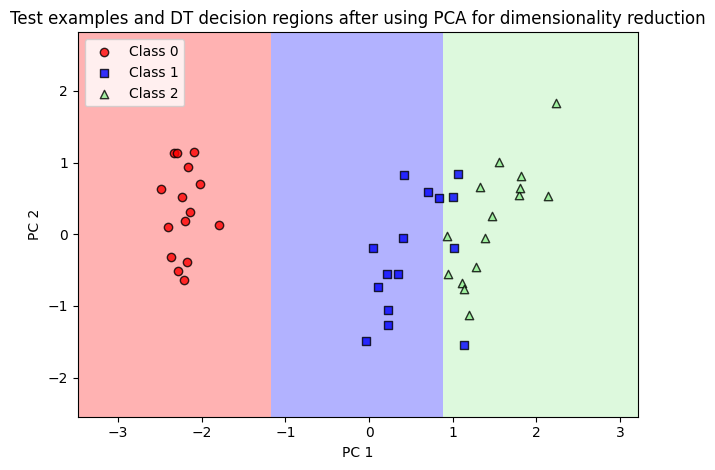

In [19]:
plot_decision_regions(X_test_pca, y_test, classifier=tree_model)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='upper left')
plt.title('Test examples and DT decision regions after using PCA for dimensionality reduction')
plt.tight_layout()
plt.show()

**P 1.3** (1 point) Assess feature contributions by plotting feature correlations with the first principal component as shown in Figure 5.6 (p. 153)

In [20]:
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat) # note : if eigh() is used, you must sort it in descending order first
loadings = eigen_vecs * np.sqrt(eigen_vals)
loadings[:, 0]

array([ 0.89499611, -0.43054983,  0.99755402,  0.97187755])

In [21]:
# If you use scikit-learn
sklearn_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
sklearn_loadings[:,0]

array([ 0.89499611, -0.43054983,  0.99755402,  0.97187755])

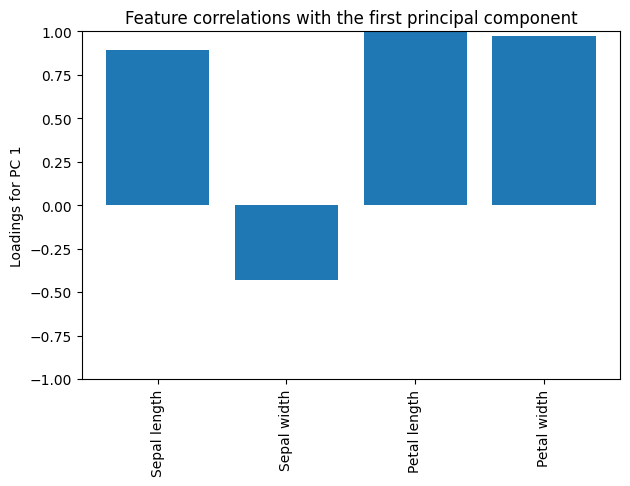

In [22]:
fig, ax = plt.subplots()

# ax.bar(range(4), loadings[:, 0], align='center')
ax.bar(range(4), sklearn_loadings[:, 0], align='center') # sk-learn version

ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(4))
feature_list = ['Sepal length','Sepal width','Petal length','Petal width']
ax.set_xticklabels(feature_list, rotation=90)

plt.ylim([-1, 1])
plt.tight_layout()
plt.title('Feature correlations with the first principal component')
plt.show()

<a id="p2"></a>
#### P2. (5 points) 

From lecture 8 notebook, we implement a simple k-means algorithm

In [23]:
class k_Means_2D:
    def __init__(self, n_clusters=3,max_iter=50,tol=1e-3, random_state = 1):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol 
        self.random_state = random_state
        self.num_samples = X.shape[0]
        rgen = np.random.RandomState(self.random_state)
        self.cluster_centroids_ = rgen.normal(loc=0.0, scale=1.0, size=(self.n_clusters,2))
        # self.cluster_centroids_[1,:] += np.array([1.0,3.0])  # This results in local minimum
        self.cluster_centroids_[2,:] += 3.0
        self.y = np.zeros((self.num_samples),dtype=int)
        self.errors = 1.0 

    def step(self,X):  # progress each step according to (8.1),(8.2) 
        # (8.1)
        for i in range(self.num_samples): 
            self.y[i] = np.argmin(np.linalg.norm(X[i,:] - self.cluster_centroids_,ord=2,axis=1)**2)
        return self.y

    def compute_new_centroids(self):
        # (8.2)
        old_centroids = self.cluster_centroids_
        self.cluster_centroids_ = np.zeros((3,2))
        for i in range(self.num_samples):
            for j in range(self.n_clusters):
                self.cluster_centroids_[j,:] += np.where(self.y[i]==j,X[i,:],0)
        bincounts = np.bincount(self.y) # must make sure that each class has some examples
        for j in range(self.n_clusters):
            self.cluster_centroids_[j] /= bincounts[j]
        self.errors = np.linalg.norm(self.cluster_centroids_ - old_centroids)

    def fit_predict(self, X):
        n_iter = 0
        while n_iter < self.max_iter and self.errors > self.tol:
            self.step(X)
            self.compute_new_centroids()
            n_iter += 1
        print("Iteration : "+ str(n_iter))
        print("Centroid change : " + str(self.errors))
        return self.y

**P 2.1 :** (2 points) Some lines are hard-coded in the k_Means_2D class above, for illustration with 3 clusters. Adjust it so that it works with any number of clusters up to 10. 

**Note :** You're gonna have trouble with centroid initialization. When some centroid has no data sample assigned to it, that would lead to error. Read chapter 10 of [1] (p. 311) for some strategy to fix it, though you do not have to implement that entirely (called k-means++). Indeed, you can try a simplified version by choosing data samples as centroids and find some way to spread them as much as possible. This makes sure that each centroid has at least one data sample in its cluster.

**P 2.2 :** (2 points) To test it, use make_blobs() in scikit-learn to create a clustered dataset with more centers such as 7. Your implementation should be able to perform clustering properly. It may result in local minimum depending on initial centroids. That's OK for this homework. Plot the clustering result as in lecture 8 notebook. Note that your plot function must be flexible enough to handle arbitrary number of clusters up to 10 without error.

**P 2.3 :** (1 point) Use scikit-learn to compare with your implementaion. 

### Solution


Modified class implementation to support arbritary number of clusters.

In [24]:
rgen = np.random.RandomState(1)
rgen.choice(100)

37

In [25]:
def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points."""
    return np.sqrt(np.sum((point1 - point2)**2))

class k_Means_2D:
    def __init__(self, n_clusters=3,max_iter=50,tol=1e-3, random_state = 1):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol 
        self.random_state = random_state
        self.num_samples = X.shape[0]
        self.rgen = np.random.RandomState(self.random_state)
        # this random intialization method won't work well
        # self.cluster_centers_ = rgen.normal(loc=0.0, scale=10.0, size=(self.n_clusters,2))
        self.y = np.zeros((self.num_samples),dtype=int)
        self.errors = 1.0 

    # create a method to spread initial centroids as much as possible
    def select_initial_centroids(self): 
        """
        Centroid initialization algorithm. Resemble k-means++.
        """

        self.cluster_centers_ = np.zeros((self.n_clusters,2)) # create arrays to keep centroids
        center_index = -np.ones((self.n_clusters),dtype=np.int64) # array to keep indices of data samples
                                                                # used as centroids
        # 1. Choose the first centroid uniformly at random from the data points.                                                        
        center_index[0] = self.rgen.choice(self.num_samples) 
        self.cluster_centers_[0,:] = X[center_index[0],:] 

        # 2. For each subsequent centroid, choose a data point with probability
        # proportional to its squared distance to the closest existing centroid.
        for i in range(1,self.n_clusters): # select other centroids
            # print("===========")
            # print("i = "+str(i))
            distances = np.array([min([euclidean_distance(point, c)**2 for c in self.cluster_centers_[:i]]) for point in X])
            probabilities = distances / np.sum(distances)
            center_index[i] = self.rgen.choice(self.num_samples, p=probabilities)
            self.cluster_centers_[i,:] = X[center_index[i],:]


    def step(self,X):  # progress each step according to (8.1),(8.2) 
        # new code
        # (8.1)
        self.y = np.array([np.argmin([euclidean_distance(point, c) for c in self.cluster_centers_]) for point in X])
        # old code
        # (8.1)
        # for i in range(self.num_samples): 
        #     self.y[i] = np.argmin(np.linalg.norm(X[i,:] - self.cluster_centers_,ord=2,axis=1)**2)

        return self.y

    def compute_new_centroids(self):
        # (8.2)
        # new code from AI
        old_centroids = self.cluster_centers_
        for cluster_id in range(self.n_clusters):
            points_in_cluster = X[self.y == cluster_id]
            if len(points_in_cluster) > 0:
                self.cluster_centers_[cluster_id] = np.mean(points_in_cluster, axis=0)
            else:
                # Handle empty clusters by re-initializing the centroid
                self.cluster_centers_[cluster_id] = X[self.rgen.choice(self.num_samples)]

        # old code 
        # (8.2)
        # old_centroids = self.cluster_centers_
        # self.cluster_centers_ = np.zeros((self.n_clusters,2))
        # for i in range(self.num_samples):
        #     for j in range(self.n_clusters):
        #         self.cluster_centers_[j,:] += np.where(self.y[i]==j,X[i,:],0)
        # bincounts = np.bincount(self.y) # must make sure that each class has some examples
        # for j in range(self.n_clusters):
        #     self.cluster_centers_[j] /= bincounts[j]

        self.errors = np.linalg.norm(self.cluster_centers_ - old_centroids)

    def fit_predict(self, X):
        n_iter = 1
        self.select_initial_centroids()
        self.step(X)
        while n_iter < self.max_iter and self.errors > self.tol:            
            self.compute_new_centroids()
            self.step(X)
            n_iter += 1
        print("Iteration : "+ str(n_iter))
        print("Centroid change : " + str(self.errors))
        return self.y

Test with 9 clusters data.

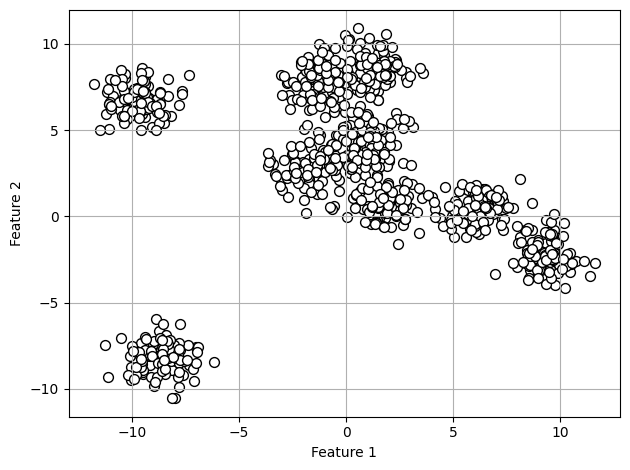

In [26]:
from sklearn.datasets import make_blobs

num_centers = 9  # change this to test

X, y = make_blobs(n_samples=900, 
                  n_features=2, 
                  centers=num_centers, 
                  cluster_std=0.9, 
                  shuffle=True, 
                  random_state=0)

plt.scatter(X[:, 0], X[:, 1], 
            c='white', marker='o', edgecolor='black', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.grid()
plt.tight_layout()
plt.show()


In [27]:
# plot function
def plot_km(X,y,km):
    plt.figure()
    colors = ['r', 'b', 'g','c','m','y','k','darkorange','darkgreen','darkcyan']
    markers = ['o', 's', '^','<','>','1','2','p','h','x']
    for l, c, m in zip(np.unique(y), colors, markers):
        plt.scatter(X[y == l, 0], 
                    X[y == l, 1], 
                    s=50,c=c, label=f'Cluster {l}', marker=m)
        

    plt.scatter(km.cluster_centers_[:, 0],
                km.cluster_centers_[:, 1],
                s=250, marker='*',
                c='red', edgecolor='black',
                label='Centroids')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    plt.legend(scatterpoints=1)
    plt.grid()
    plt.tight_layout()
    plt.show()    

In [28]:
my_km = k_Means_2D(n_clusters=num_centers,random_state = 30)

In [29]:
my_km.select_initial_centroids()

In [30]:
my_km.cluster_centers_

array([[-8.6114473 , -7.95499984],
       [ 9.77362162, -1.52794312],
       [-8.81352634,  6.81816005],
       [ 1.74121356,  9.00466528],
       [ 1.11572276,  4.6441336 ],
       [-2.09333919,  8.75077891],
       [ 5.88415498,  0.84697811],
       [ 1.77715585, -0.61073977],
       [ 0.2854031 ,  8.06156407]])

In [31]:
my_y_km = my_km.step(X)

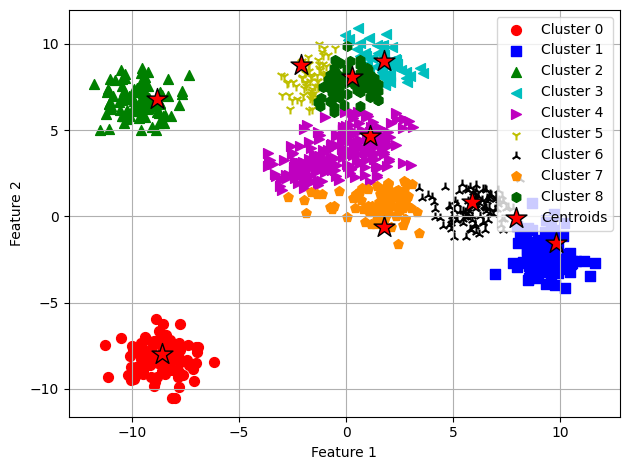

In [32]:
plot_km(X,my_y_km,my_km)

In [33]:
my_km.compute_new_centroids()

Iteration : 2
Centroid change : 0.0


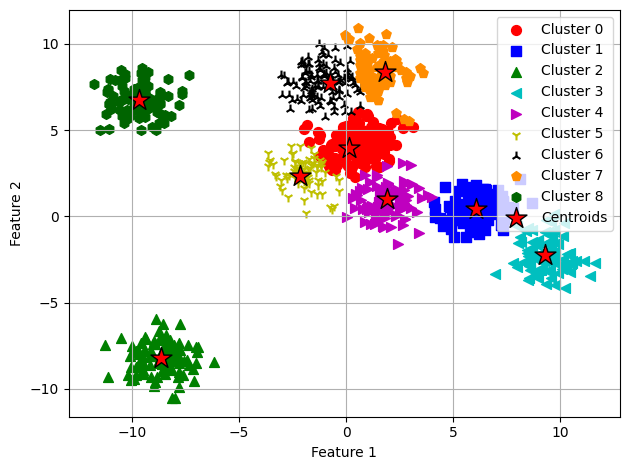

In [34]:
# Try changing random_state, 45 yields good result 
my_km = k_Means_2D(n_clusters=num_centers,random_state = 45) 
my_y_km = my_km.fit_predict(X)
plot_km(X,my_y_km,my_km)

Compare with scikit-learn.

In [35]:
from sklearn.cluster import KMeans


km = KMeans(n_clusters=num_centers, 
            init='random', 
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_km = km.fit_predict(X)

c:\Users\dewpl\.julia\conda\3\x86_64\envs\mlpi\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


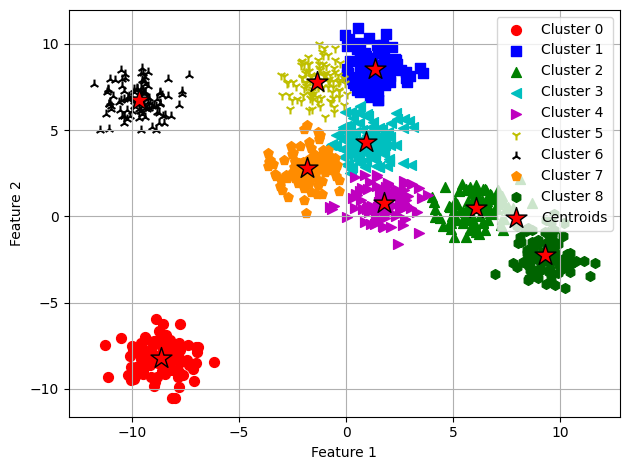

In [36]:
plot_km(X,y_km,km)

### References

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) pp. 134-136. Packt Publishing. 2022. 

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2025</div>

##### Rev. 1A : October 2025